# Изучаю количество уникальных выходных переменных

In [3]:
import os
import json
from collections import Counter

def analyze_diagnoses_with_top10(folder_path):
    """
    Анализ диагнозов с выводом полного списка и отдельно топ-10
    """
    diagnosis_counter = Counter()
    total_files = 0
    processed_files = 0
    
    if not os.path.exists(folder_path):
        print(f"Ошибка: Папка '{folder_path}' не существует!")
        return
    
    # Анализируем файлы
    for filename in os.listdir(folder_path):
        if filename.endswith('.json'):
            total_files += 1
            file_path = os.path.join(folder_path, filename)
            
            try:
                with open(file_path, 'r', encoding='utf-8') as file:
                    data = json.load(file)
                
                if 'diagnosis' in data and 'diagnosis_text' in data['diagnosis']:
                    diagnosis_text = data['diagnosis']['diagnosis_text']
                    if diagnosis_text:
                        diagnosis_counter[diagnosis_text] += 1
                        processed_files += 1
                        
            except Exception as e:
                print(f"Ошибка в файле {filename}: {e}")
    
    # ВЫВОД ТОП-10 ОТДЕЛЬНО
    print("="*60)
    print("ТОП-10 САМЫХ ЧАСТЫХ ДИАГНОЗОВ")
    print("="*60)
    
    top_10 = diagnosis_counter.most_common(10)
    for i, (diagnosis, count) in enumerate(top_10, 1):
        percentage = (count / processed_files) * 100
        print(f"{i:2d}. {diagnosis:<15} - {count:3d} случаев ({percentage:6.1f}%)")
    
    # Общая статистика по топ-10
    top_10_total_cases = sum(count for _, count in top_10)
    top_10_percentage = (top_10_total_cases / processed_files) * 100
    print(f"\nТоп-10 диагнозов покрывают: {top_10_total_cases}/{processed_files} случаев ({top_10_percentage:.1f}%)")
    
    # ВЫВОД ПОЛНОГО СПИСКА ВСЕХ ДИАГНОЗОВ
    print("\n" + "="*60)
    print(f"ПОЛНЫЙ СПИСОК ВСЕХ ДИАГНОЗОВ ({len(diagnosis_counter)} видов)")
    print("="*60)
    
    for i, (diagnosis, count) in enumerate(diagnosis_counter.most_common(), 1):
        percentage = (count / processed_files) * 100
        print(f"{i:2d}. {diagnosis:<15} - {count:3d} случаев ({percentage:6.1f}%)")
    
    # ОБЩАЯ СТАТИСТИКА
    print("\n" + "="*60)
    print("ОБЩАЯ СТАТИСТИКА")
    print("="*60)
    print(f"Всего файлов: {total_files}")
    print(f"Файлов с диагнозами: {processed_files}")
    print(f"Уникальных диагнозов: {len(diagnosis_counter)}")
    
    # Дополнительная информация
    single_occurrence = sum(1 for count in diagnosis_counter.values() if count == 1)
    print(f"Диагнозы, встречающиеся 1 раз: {single_occurrence}")
    print(f"Диагнозы, встречающиеся >1 раза: {len(diagnosis_counter) - single_occurrence}")

# Альтернативный вариант с более красивым форматированием
def analyze_diagnoses_pretty(folder_path):
    """
    Красивое форматирование вывода
    """
    diagnosis_counter = Counter()
    processed_files = 0
    
    # Собираем данные
    for filename in os.listdir(folder_path):
        if filename.endswith('.json'):
            file_path = os.path.join(folder_path, filename)
            
            try:
                with open(file_path, 'r', encoding='utf-8') as file:
                    data = json.load(file)
                
                if 'diagnosis' in data and 'diagnosis_text' in data['diagnosis']:
                    diagnosis_text = data['diagnosis']['diagnosis_text']
                    if diagnosis_text:
                        diagnosis_counter[diagnosis_text] += 1
                        processed_files += 1
            except Exception:
                continue
    
    # ТОП-10 в красивом формате
    print("🎯 ТОП-10 САМЫХ ЧАСТЫХ ДИАГНОЗОВ")
    print("═" * 50)
    
    top_10 = diagnosis_counter.most_common(10)
    max_diagnosis_len = max(len(diagnosis) for diagnosis, _ in top_10)
    
    for i, (diagnosis, count) in enumerate(top_10, 1):
        percentage = (count / processed_files) * 100
        bar = "█" * int(percentage / 2)  # Визуализация в процентах
        print(f"{i:2d}. {diagnosis:<{max_diagnosis_len}} - {count:3d} 📊 {percentage:5.1f}% {bar}")
    
    # Полный список
    print(f"\n📋 ПОЛНЫЙ СПИСОК ДИАГНОЗОВ ({len(diagnosis_counter)} видов)")
    print("═" * 50)
    
    all_diagnoses = diagnosis_counter.most_common()
    for i, (diagnosis, count) in enumerate(all_diagnoses, 1):
        percentage = (count / processed_files) * 100
        print(f"{i:2d}. {diagnosis:<{max_diagnosis_len}} - {count:3d} случаев ({percentage:5.1f}%)")

# Компактный вариант
def analyze_diagnoses_compact(folder_path):
    """
    Компактный вывод
    """
    diagnosis_counter = Counter()
    processed_files = 0
    
    # Собираем данные
    for filename in os.listdir(folder_path):
        if filename.endswith('.json'):
            file_path = os.path.join(folder_path, filename)
            
            try:
                with open(file_path, 'r', encoding='utf-8') as file:
                    data = json.load(file)
                
                if 'diagnosis' in data and 'diagnosis_text' in data['diagnosis']:
                    diagnosis_text = data['diagnosis']['diagnosis_text']
                    if diagnosis_text:
                        diagnosis_counter[diagnosis_text] += 1
                        processed_files += 1
            except Exception:
                continue
    
    # ТОП-10
    print("ТОП-10 ДИАГНОЗОВ:")
    print("-" * 40)
    top_10 = diagnosis_counter.most_common(10)
    for i, (diagnosis, count) in enumerate(top_10, 1):
        percentage = (count / processed_files) * 100
        print(f"{i}. {diagnosis} - {count} ({percentage:.1f}%)")
    
    # Все диагнозы
    print(f"\nВСЕ ДИАГНОЗЫ ({len(diagnosis_counter)}):")
    print("-" * 40)
    all_diagnoses = diagnosis_counter.most_common()
    for i, (diagnosis, count) in enumerate(all_diagnoses, 1):
        percentage = (count / processed_files) * 100
        print(f"{i:2d}. {diagnosis} - {count} ({percentage:.1f}%)")

# Запуск анализа
folder_path = "preprocessed_medical_results"

print("Анализ медицинских диагнозов")
print("Папка:", folder_path)
print()

# Выберите один из вариантов:
analyze_diagnoses_with_top10(folder_path)  # Основной вариант
# analyze_diagnoses_pretty(folder_path)     # Красивый вариант с emoji
# analyze_diagnoses_compact(folder_path)    # Компактный вариант

Анализ медицинских диагнозов
Папка: preprocessed_medical_results

ТОП-10 САМЫХ ЧАСТЫХ ДИАГНОЗОВ
 1. J44.8           - 204 случаев (  10.1%)
 2. D14.3           - 185 случаев (   9.2%)
 3. U07.1           - 167 случаев (   8.3%)
 4. A15.0           - 163 случаев (   8.1%)
 5. C34.1           - 155 случаев (   7.7%)
 6. C34.3           - 119 случаев (   5.9%)
 7. J44.1           - 118 случаев (   5.9%)
 8. J15.8           -  91 случаев (   4.5%)
 9. A16.0           -  84 случаев (   4.2%)
10. J45.9           -  70 случаев (   3.5%)

Топ-10 диагнозов покрывают: 1356/2010 случаев (67.5%)

ПОЛНЫЙ СПИСОК ВСЕХ ДИАГНОЗОВ (52 видов)
 1. J44.8           - 204 случаев (  10.1%)
 2. D14.3           - 185 случаев (   9.2%)
 3. U07.1           - 167 случаев (   8.3%)
 4. A15.0           - 163 случаев (   8.1%)
 5. C34.1           - 155 случаев (   7.7%)
 6. C34.3           - 119 случаев (   5.9%)
 7. J44.1           - 118 случаев (   5.9%)
 8. J15.8           -  91 случаев (   4.5%)
 9. A16.0       

# Отедляем только файлы, где диагнозы входят в топ 7

In [4]:
import os
import json
import shutil
from collections import Counter

def copy_top7_diagnoses_files(source_folder, target_folder):
    """
    Копирует в новую папку только файлы с диагнозами из топ-7 самых частых
    """
    diagnosis_counter = Counter()
    processed_files = 0
    file_diagnosis_map = {}  # Словарь для связи файл -> диагноз
    
    if not os.path.exists(source_folder):
        print(f"Ошибка: Папка '{source_folder}' не существует!")
        return
    
    # Создаем целевую папку, если её нет
    if not os.path.exists(target_folder):
        os.makedirs(target_folder)
        print(f"Создана папка: {target_folder}")
    
    # Сначала анализируем все файлы и собираем статистику
    print("Анализируем диагнозы...")
    for filename in os.listdir(source_folder):
        if filename.endswith('.json'):
            file_path = os.path.join(source_folder, filename)
            
            try:
                with open(file_path, 'r', encoding='utf-8') as file:
                    data = json.load(file)
                
                if 'diagnosis' in data and 'diagnosis_text' in data['diagnosis']:
                    diagnosis_text = data['diagnosis']['diagnosis_text']
                    if diagnosis_text:
                        diagnosis_counter[diagnosis_text] += 1
                        file_diagnosis_map[filename] = diagnosis_text
                        processed_files += 1
                        
            except Exception as e:
                print(f"Ошибка при чтении файла {filename}: {e}")
    
    # Определяем топ-7 диагнозов
    top_7_diagnoses = [diagnosis for diagnosis, count in diagnosis_counter.most_common(7)]
    
    print("\n" + "="*50)
    print("ТОП-7 САМЫХ ЧАСТЫХ ДИАГНОЗОВ")
    print("="*50)
    
    for i, (diagnosis, count) in enumerate(diagnosis_counter.most_common(7), 1):
        percentage = (count / processed_files) * 100
        print(f"{i}. {diagnosis} - {count} случаев ({percentage:.1f}%)")
    
    # Копируем файлы с диагнозами из топ-7
    copied_files = 0
    print(f"\nКопируем файлы с топ-7 диагнозами в папку: {target_folder}")
    print("-" * 50)
    
    for filename, diagnosis in file_diagnosis_map.items():
        if diagnosis in top_7_diagnoses:
            source_path = os.path.join(source_folder, filename)
            target_path = os.path.join(target_folder, filename)
            
            try:
                shutil.copy2(source_path, target_path)
                copied_files += 1
                print(f"✓ Скопирован: {filename} (диагноз: {diagnosis})")
            except Exception as e:
                print(f"✗ Ошибка при копировании {filename}: {e}")
    
    # Статистика по скопированным файлам
    print("\n" + "="*50)
    print("РЕЗУЛЬТАТЫ КОПИРОВАНИЯ")
    print("="*50)
    print(f"Всего обработано файлов: {processed_files}")
    print(f"Скопировано файлов с топ-7 диагнозами: {copied_files}")
    print(f"Процент от общего количества: {(copied_files/processed_files)*100:.1f}%")
    
    # Детальная статистика по каждому диагнозу из топ-7
    print(f"\nДЕТАЛЬНАЯ СТАТИСТИКА ПО ТОП-7:")
    print("-" * 40)
    
    for diagnosis in top_7_diagnoses:
        count_in_top = sum(1 for d in file_diagnosis_map.values() if d == diagnosis)
        print(f"{diagnosis}: {count_in_top} файлов")
    
    return copied_files, top_7_diagnoses

# Дополнительная функция для проверки результатов
def verify_copied_files(target_folder, top_7_diagnoses):
    """
    Проверяет корректность скопированных файлов
    """
    print(f"\n" + "="*50)
    print("ПРОВЕРКА СКОПИРОВАННЫХ ФАЙЛОВ")
    print("="*50)
    
    if not os.path.exists(target_folder):
        print("Целевая папка не существует!")
        return
    
    files_in_target = [f for f in os.listdir(target_folder) if f.endswith('.json')]
    print(f"Файлов в целевой папке: {len(files_in_target)}")
    
    # Проверяем диагнозы в скопированных файлах
    diagnosis_count = Counter()
    
    for filename in files_in_target:
        file_path = os.path.join(target_folder, filename)
        
        try:
            with open(file_path, 'r', encoding='utf-8') as file:
                data = json.load(file)
            
            if 'diagnosis' in data and 'diagnosis_text' in data['diagnosis']:
                diagnosis_text = data['diagnosis']['diagnosis_text']
                if diagnosis_text:
                    diagnosis_count[diagnosis_text] += 1
                    
        except Exception as e:
            print(f"Ошибка при проверке файла {filename}: {e}")
    
    print("\nДиагнозы в скопированных файлах:")
    for diagnosis, count in diagnosis_count.most_common():
        status = "✓ В топ-7" if diagnosis in top_7_diagnoses else "✗ НЕ в топ-7"
        print(f"  {diagnosis}: {count} файлов {status}")

# Основная функция
def main():
    source_folder = "preprocessed_medical_results"
    target_folder = "top7_diagnoses_files"
    
    # Копируем файлы с топ-7 диагнозами
    copied_files, top_7_diagnoses = copy_top7_diagnoses_files(source_folder, target_folder)
    
    # Проверяем результат
    verify_copied_files(target_folder, top_7_diagnoses)
    
    print(f"\n🎉 Готово! Файлы с топ-7 диагнозами сохранены в папку: {target_folder}")

# Альтернативный вариант с фильтрацией по конкретным диагнозам
def filter_specific_diagnoses(source_folder, target_folder, diagnoses_to_keep):
    """
    Фильтрует файлы по конкретным диагнозам
    """
    if not os.path.exists(source_folder):
        print(f"Ошибка: Папка '{source_folder}' не существует!")
        return
    
    # Создаем целевую папку
    if not os.path.exists(target_folder):
        os.makedirs(target_folder)
    
    copied_files = 0
    total_files = 0
    
    print(f"Фильтруем файлы по диагнозам: {diagnoses_to_keep}")
    print("-" * 50)
    
    for filename in os.listdir(source_folder):
        if filename.endswith('.json'):
            total_files += 1
            file_path = os.path.join(source_folder, filename)
            
            try:
                with open(file_path, 'r', encoding='utf-8') as file:
                    data = json.load(file)
                
                if 'diagnosis' in data and 'diagnosis_text' in data['diagnosis']:
                    diagnosis_text = data['diagnosis']['diagnosis_text']
                    
                    if diagnosis_text in diagnoses_to_keep:
                        target_path = os.path.join(target_folder, filename)
                        shutil.copy2(file_path, target_path)
                        copied_files += 1
                        print(f"✓ {filename} - {diagnosis_text}")
                        
            except Exception as e:
                print(f"✗ Ошибка в файле {filename}: {e}")
    
    print(f"\nСкопировано {copied_files} из {total_files} файлов")

# Запуск
if __name__ == "__main__":
    main()
    
    # Если хотите вручную указать диагнозы для фильтрации:
    # specific_diagnoses = ["J15.8", "J18.9", "I10", "E11.9", "I25.1", "J45.9", "N18.3"]
    # filter_specific_diagnoses("preprocessed_medical_results", "filtered_diagnoses", specific_diagnoses)

Создана папка: top7_diagnoses_files
Анализируем диагнозы...

ТОП-7 САМЫХ ЧАСТЫХ ДИАГНОЗОВ
1. J44.8 - 204 случаев (10.1%)
2. D14.3 - 185 случаев (9.2%)
3. U07.1 - 167 случаев (8.3%)
4. A15.0 - 163 случаев (8.1%)
5. C34.1 - 155 случаев (7.7%)
6. C34.3 - 119 случаев (5.9%)
7. J44.1 - 118 случаев (5.9%)

Копируем файлы с топ-7 диагнозами в папку: top7_diagnoses_files
--------------------------------------------------
✓ Скопирован: processed_Эпикриз_1503_v1.json (диагноз: A15.0)
✓ Скопирован: processed_Эпикриз_1504_v1.json (диагноз: A15.0)
✓ Скопирован: processed_Эпикриз_1510_v1.json (диагноз: J44.8)
✓ Скопирован: processed_Эпикриз_1511_v1.json (диагноз: U07.1)
✓ Скопирован: processed_Эпикриз_1512_v1.json (диагноз: J44.8)
✓ Скопирован: processed_Эпикриз_1513_v1.json (диагноз: U07.1)
✓ Скопирован: processed_Эпикриз_1556_v1.json (диагноз: C34.3)
✓ Скопирован: processed_Эпикриз_1560_v1.json (диагноз: J44.8)
✓ Скопирован: processed_Эпикриз_1564_v1.json (диагноз: J44.8)
✓ Скопирован: processed_Э

# Анализируем дисбаланс

📊 АНАЛИЗ ДИСБАЛАНСА КЛАССОВ

📈 БАЗОВАЯ СТАТИСТИКА:
----------------------------------------
Всего файлов: 1111
Количество классов: 7
Среднее количество на класс: 158.7

📋 РАСПРЕДЕЛЕНИЕ КЛАССОВ:
--------------------------------------------------
Диагноз    Количество   Процент    Отн. частота   
--------------------------------------------------
J44.8      204          18.4      % 1.7            x
D14.3      185          16.7      % 1.6            x
U07.1      167          15.0      % 1.4            x
A15.0      163          14.7      % 1.4            x
C34.1      155          14.0      % 1.3            x
C34.3      119          10.7      % 1.0            x
J44.1      118          10.6      % 1.0            x

⚖️ СТАТИСТИКА ДИСБАЛАНСА:
----------------------------------------
Самый частый класс: 204 файлов
Самый редкий класс: 118 файлов
Соотношение дисбаланса: 1.7:1
Коэффициент вариации: 18.6%
Стандартное отклонение: 29.5

🎯 УРОВЕНЬ ДИСБАЛАНСА:
----------------------------------------
С

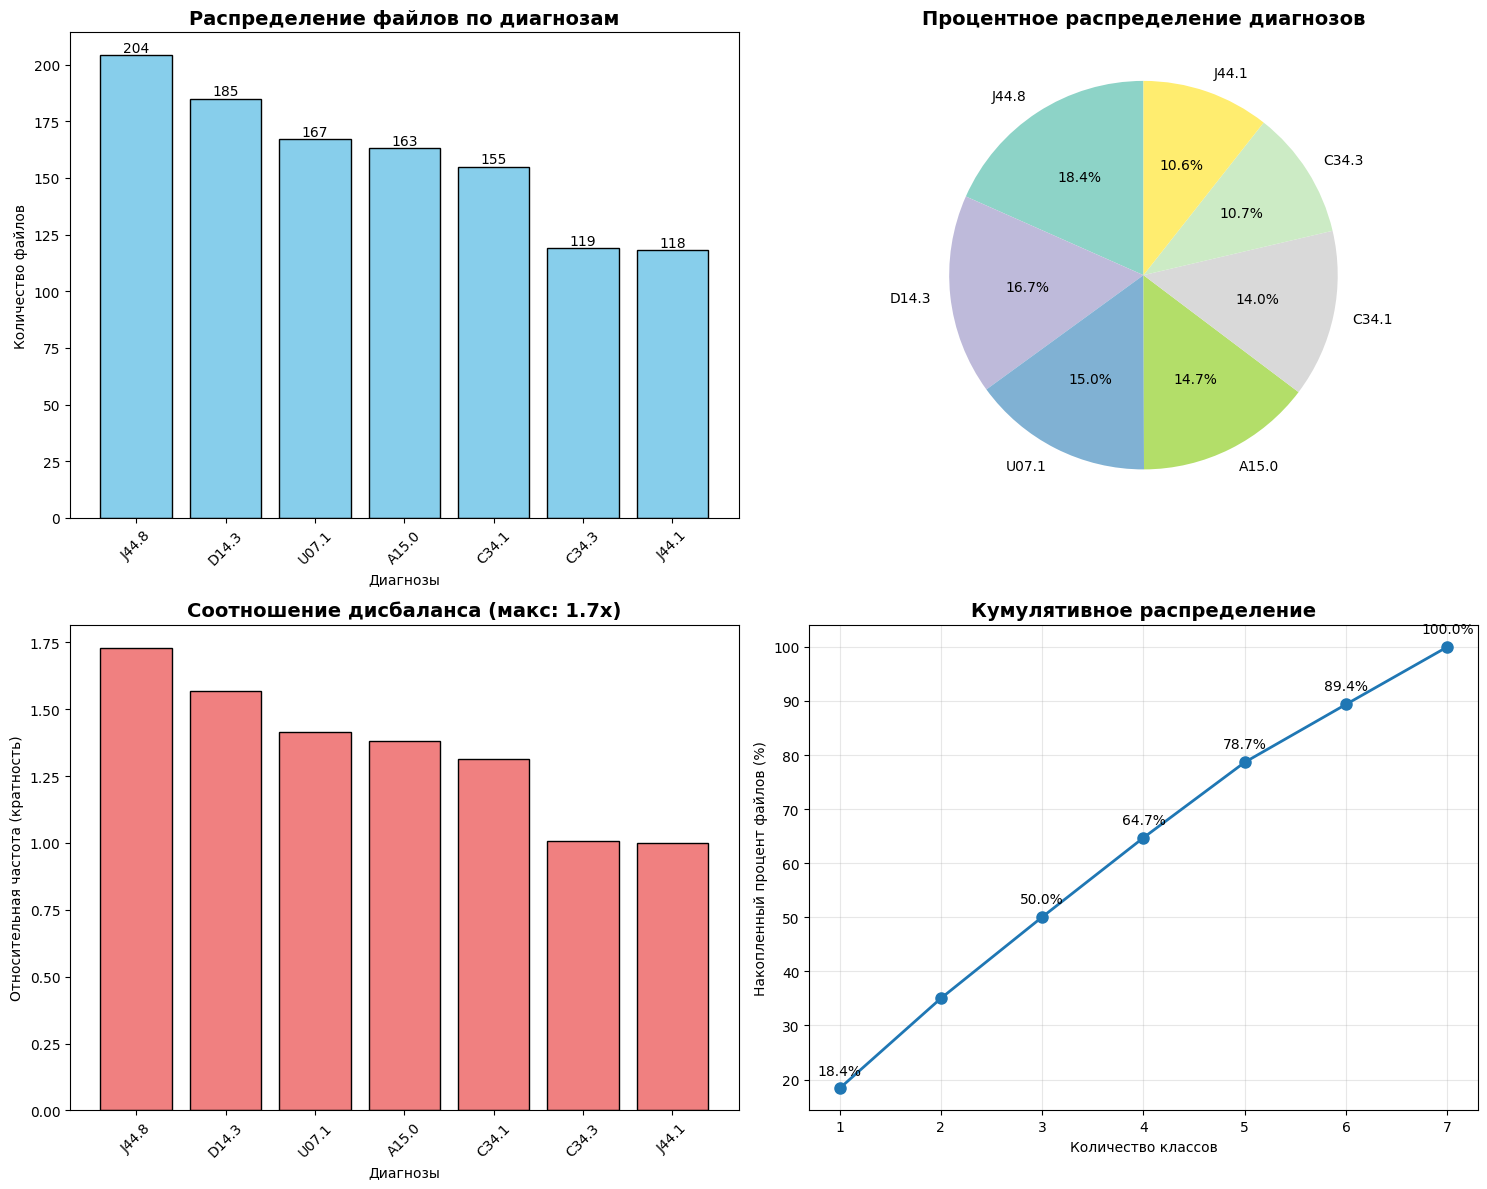


📊 ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ:
----------------------------------------
Топ-1 классов покрывают: 18.4% данных
Топ-2 классов покрывают: 35.0% данных
Топ-3 классов покрывают: 50.0% данных
Топ-4 классов покрывают: 64.7% данных

Анализ по квантилям:
25-й перцентиль: 137.0 файлов
50-й перцентиль (медиана): 163.0 файлов
75-й перцентиль: 176.0 файлов

Классификация классов:
Мажоритарные классы (>1.5x среднего): 0
Миноритарные классы (<0.5x среднего): 0


In [5]:
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from collections import Counter
import numpy as np

def analyze_class_imbalance(folder_path):
    """
    Комплексный анализ дисбаланса классов в папке с топ-7 диагнозами
    """
    if not os.path.exists(folder_path):
        print(f"Ошибка: Папка '{folder_path}' не существует!")
        return
    
    # Собираем данные о диагнозах
    diagnosis_counter = Counter()
    total_files = 0
    
    print("📊 АНАЛИЗ ДИСБАЛАНСА КЛАССОВ")
    print("=" * 60)
    
    # Читаем файлы и считаем диагнозы
    for filename in os.listdir(folder_path):
        if filename.endswith('.json'):
            file_path = os.path.join(folder_path, filename)
            
            try:
                with open(file_path, 'r', encoding='utf-8') as file:
                    data = json.load(file)
                
                if 'diagnosis' in data and 'diagnosis_text' in data['diagnosis']:
                    diagnosis_text = data['diagnosis']['diagnosis_text']
                    if diagnosis_text:
                        diagnosis_counter[diagnosis_text] += 1
                        total_files += 1
                        
            except Exception as e:
                print(f"Ошибка при чтении файла {filename}: {e}")
    
    if total_files == 0:
        print("В папке не найдено файлов с диагнозами!")
        return
    
    # Сортируем по убыванию частоты
    diagnoses_sorted = diagnosis_counter.most_common()
    
    # БАЗОВАЯ СТАТИСТИКА
    print(f"\n📈 БАЗОВАЯ СТАТИСТИКА:")
    print("-" * 40)
    print(f"Всего файлов: {total_files}")
    print(f"Количество классов: {len(diagnosis_counter)}")
    print(f"Среднее количество на класс: {total_files/len(diagnosis_counter):.1f}")
    
    # РАСПРЕДЕЛЕНИЕ КЛАССОВ
    print(f"\n📋 РАСПРЕДЕЛЕНИЕ КЛАССОВ:")
    print("-" * 50)
    print(f"{'Диагноз':<10} {'Количество':<12} {'Процент':<10} {'Отн. частота':<15}")
    print("-" * 50)
    
    for diagnosis, count in diagnoses_sorted:
        percentage = (count / total_files) * 100
        relative_freq = count / min(diagnosis_counter.values())
        print(f"{diagnosis:<10} {count:<12} {percentage:<10.1f}% {relative_freq:<15.1f}x")
    
    # СТАТИСТИКА ДИСБАЛАНСА
    print(f"\n⚖️ СТАТИСТИКА ДИСБАЛАНСА:")
    print("-" * 40)
    
    counts = [count for _, count in diagnoses_sorted]
    max_count = max(counts)
    min_count = min(counts)
    mean_count = np.mean(counts)
    std_count = np.std(counts)
    
    imbalance_ratio = max_count / min_count
    cv = (std_count / mean_count) * 100  # Коэффициент вариации
    
    print(f"Самый частый класс: {max_count} файлов")
    print(f"Самый редкий класс: {min_count} файлов")
    print(f"Соотношение дисбаланса: {imbalance_ratio:.1f}:1")
    print(f"Коэффициент вариации: {cv:.1f}%")
    print(f"Стандартное отклонение: {std_count:.1f}")
    
    # УРОВЕНЬ ДИСБАЛАНСА
    print(f"\n🎯 УРОВЕНЬ ДИСБАЛАНСА:")
    print("-" * 40)
    
    if imbalance_ratio < 2:
        level = "СБАЛАНСИРОВАННЫЙ"
    elif imbalance_ratio < 5:
        level = "НЕБОЛЬШОЙ ДИСБАЛАНС"
    elif imbalance_ratio < 10:
        level = "ЗНАЧИТЕЛЬНЫЙ ДИСБАЛАНС"
    else:
        level = "СИЛЬНЫЙ ДИСБАЛАНС"
    
    print(f"{level} (соотношение: {imbalance_ratio:.1f}:1)")
    
    # РЕКОМЕНДАЦИИ
    print(f"\n💡 РЕКОМЕНДАЦИИ:")
    print("-" * 40)
    
    if imbalance_ratio > 10:
        print("• Используйте oversampling (SMOTE) для миноритарных классов")
        print("• Используйте undersampling для мажоритарных классов")
        print("• Применяйте взвешенные функции потерь")
        print("• Рассмотрите ансамблирование методов")
    elif imbalance_ratio > 5:
        print("• Рекомендуется SMOTE или ADASYN")
        print("• Используйте взвешенные классы в алгоритмах")
        print("• Попробуйте комбинацию oversampling/undersampling")
    elif imbalance_ratio > 2:
        print("• Можно использовать простой oversampling")
        print("• Взвешивание классов может помочь")
        print("• Мониторуйте метрики для миноритарных классов")
    else:
        print("• Дисбаланс незначительный, можно использовать стандартные методы")
    
    # ВИЗУАЛИЗАЦИЯ
    visualize_imbalance(diagnoses_sorted, total_files, imbalance_ratio)
    
    # ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ
    additional_analysis(diagnoses_sorted, total_files)

def visualize_imbalance(diagnoses_sorted, total_files, imbalance_ratio):
    """
    Визуализация дисбаланса классов
    """
    diagnoses, counts = zip(*diagnoses_sorted)
    
    # Создаем графики
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
    
    # График 1: Столбчатая диаграмма
    bars = ax1.bar(range(len(diagnoses)), counts, color='skyblue', edgecolor='black')
    ax1.set_title('Распределение файлов по диагнозам', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Диагнозы')
    ax1.set_ylabel('Количество файлов')
    ax1.set_xticks(range(len(diagnoses)))
    ax1.set_xticklabels(diagnoses, rotation=45)
    
    # Добавляем значения на столбцы
    for bar, count in zip(bars, counts):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                f'{count}', ha='center', va='bottom', fontsize=10)
    
    # График 2: Круговая диаграмма
    colors = plt.cm.Set3(np.linspace(0, 1, len(diagnoses)))
    wedges, texts, autotexts = ax2.pie(counts, labels=diagnoses, autopct='%1.1f%%', 
                                      colors=colors, startangle=90)
    ax2.set_title('Процентное распределение диагнозов', fontsize=14, fontweight='bold')
    
    # График 3: Соотношение дисбаланса
    normalized_counts = [count / min(counts) for count in counts]
    ax3.bar(range(len(diagnoses)), normalized_counts, color='lightcoral', edgecolor='black')
    ax3.set_title(f'Соотношение дисбаланса (макс: {imbalance_ratio:.1f}x)', 
                 fontsize=14, fontweight='bold')
    ax3.set_xlabel('Диагнозы')
    ax3.set_ylabel('Относительная частота (кратность)')
    ax3.set_xticks(range(len(diagnoses)))
    ax3.set_xticklabels(diagnoses, rotation=45)
    
    # График 4: Кумулятивное распределение
    cumulative_percentage = np.cumsum(counts) / total_files * 100
    ax4.plot(range(1, len(diagnoses) + 1), cumulative_percentage, 
             marker='o', linewidth=2, markersize=8)
    ax4.set_title('Кумулятивное распределение', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Количество классов')
    ax4.set_ylabel('Накопленный процент файлов (%)')
    ax4.grid(True, alpha=0.3)
    
    # Добавляем ориентиры
    for i, (n, pct) in enumerate(zip(range(1, len(diagnoses) + 1), cumulative_percentage)):
        if pct >= 50 or i == 0 or i == len(diagnoses) - 1:
            ax4.annotate(f'{pct:.1f}%', (n, pct), textcoords="offset points", 
                        xytext=(0,10), ha='center')
    
    plt.tight_layout()
    plt.show()

def additional_analysis(diagnoses_sorted, total_files):
    """
    Дополнительный анализ дисбаланса
    """
    print(f"\n📊 ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ:")
    print("-" * 40)
    
    counts = [count for _, count in diagnoses_sorted]
    
    # Анализ покрытия
    top_n_coverage = []
    for n in [1, 2, 3, 4]:
        coverage = sum(counts[:n]) / total_files * 100
        top_n_coverage.append((n, coverage))
        print(f"Топ-{n} классов покрывают: {coverage:.1f}% данных")
    
    # Анализ по квантилям
    print(f"\nАнализ по квантилям:")
    q25 = np.percentile(counts, 25)
    q50 = np.percentile(counts, 50)
    q75 = np.percentile(counts, 75)
    
    print(f"25-й перцентиль: {q25:.1f} файлов")
    print(f"50-й перцентиль (медиана): {q50:.1f} файлов")
    print(f"75-й перцентиль: {q75:.1f} файлов")
    
    # Классификация классов
    mean_count = np.mean(counts)
    major_classes = [d for d, c in diagnoses_sorted if c > mean_count * 1.5]
    minor_classes = [d for d, c in diagnoses_sorted if c < mean_count * 0.5]
    
    print(f"\nКлассификация классов:")
    print(f"Мажоритарные классы (>1.5x среднего): {len(major_classes)}")
    print(f"Миноритарные классы (<0.5x среднего): {len(minor_classes)}")
    
    if minor_classes:
        print(f"Миноритарные классы: {', '.join(minor_classes)}")

# Анализ для исходных данных (сравнение)
def compare_with_original(source_folder, top7_folder):
    """
    Сравнивает дисбаланс в исходных данных и в топ-7
    """
    def count_diagnoses(folder):
        counter = Counter()
        for filename in os.listdir(folder):
            if filename.endswith('.json'):
                file_path = os.path.join(folder, filename)
                try:
                    with open(file_path, 'r', encoding='utf-8') as file:
                        data = json.load(file)
                    if 'diagnosis' in data and 'diagnosis_text' in data['diagnosis']:
                        diagnosis = data['diagnosis']['diagnosis_text']
                        if diagnosis:
                            counter[diagnosis] += 1
                except:
                    continue
        return counter
    
    print("\n" + "="*60)
    print("СРАВНЕНИЕ С ИСХОДНЫМИ ДАННЫМИ")
    print("="*60)
    
    original_counts = count_diagnoses(source_folder)
    top7_counts = count_diagnoses(top7_folder)
    
    original_imbalance = max(original_counts.values()) / min(original_counts.values())
    top7_imbalance = max(top7_counts.values()) / min(top7_counts.values())
    
    print(f"Исходные данные:")
    print(f"  - Классов: {len(original_counts)}")
    print(f"  - Дисбаланс: {original_imbalance:.1f}:1")
    
    print(f"\nТоп-7 данные:")
    print(f"  - Классов: {len(top7_counts)}")
    print(f"  - Дисбаланс: {top7_imbalance:.1f}:1")
    
    improvement = (original_imbalance - top7_imbalance) / original_imbalance * 100
    print(f"\nУлучшение баланса: {improvement:.1f}%")

# Запуск анализа
if __name__ == "__main__":
    folder_path = "top7_diagnoses_files"
    
    # Основной анализ дисбаланса
    analyze_class_imbalance(folder_path)
    
    # Сравнение с исходными данными (раскомментируйте если нужно)
    # compare_with_original("preprocessed_medical_results", folder_path)

По результатом анализа видно, что дисбаланс не критичный, можно работать с этим